### **ESTIMACIÓN DEL MODELO FAMA FRENCH DE TRES FACTORES**

Apuntes de: Alejandro Vargas Sanchez, PhD, CFA

alejandro.vargas@upb.edu

**1. Importamos las librerías**

In [15]:
import pandas as pd
import statistics
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter
from mlxtend.plotting import scatterplotmatrix
from pandas.plotting import scatter_matrix
from matplotlib.ticker import FormatStrFormatter

**2. Cargamos la serie de tiempo de precios de las acciones**

In [2]:
df_stock = pd.read_excel('Stock_price.xlsx', sheet_name = 'Stocks',
                   header=0, index_col=0, parse_dates=True,)

In [3]:
# Mostrar todos los tickers tal como están en el DataFrame
tickers = df_stock.columns.tolist()

print("TICKERS DISPONIBLES:")
print(tickers)

TICKERS DISPONIBLES:
['AAPL.OQ', 'F', 'TSLA.O', 'M', 'MSFT.O', 'MMM', 'T', 'DIS', 'GOOGL.O', 'AMZN.O', 'CAT', 'CSCO.O', 'C', 'DD', 'FDX', 'GM']


In [4]:
tickers_report = pd.DataFrame({
    'Ticker': tickers
})
tickers_report

,Ticker
0,AAPL.OQ
1,F
2,TSLA.O
3,M
4,MSFT.O
5,MMM
6,T
7,DIS
8,GOOGL.O
9,AMZN.O


In [46]:
# Elegir un ticker exacto del DataFrame (usa el nombre tal cual aparece)
TICKER = 'DIS'   # 👈 cámbialo por el que necesites

# Crear un DataFrame solo con esa columna
df_single = df_stock[[TICKER]]

**3. Cargamos la serie de tiempo del Índice de mercado**

In [47]:
df_market = pd.read_excel('SP500.xlsx', sheet_name = 'SP500',
                   header=0, index_col=0, parse_dates=True,)

In [48]:
# Unir con el índice de mercado (alineado por fecha)
df_general = df_single.join(df_market, how='inner')

# Ver los primeros registros
df_general.head()

,DIS,SP500
Date,,
2020-10-15,127.36,3483.34
2020-10-16,126.81,3483.81
2020-10-19,124.23,3426.92
2020-10-20,124.95,3443.12
2020-10-21,126.63,3435.56


In [49]:
# Renombrar la columna SP500 a 'Market'
df_general = df_general.rename(columns={'SP500': 'Market'})
df_general.head()

,DIS,Market
Date,,
2020-10-15,127.36,3483.34
2020-10-16,126.81,3483.81
2020-10-19,124.23,3426.92
2020-10-20,124.95,3443.12
2020-10-21,126.63,3435.56


**3. Calculamos los HPR**

Primero acotamos la muestra a periodos mensuales.

Luego calculamos el HPR con los precios de cada mes.

$HPR = \frac{P_1 + D_1 - P_0}{P_0}$

In [50]:
# Calcular los rendimientos mensuales (returns)
r = (
    df_general
    .resample('ME')        # Cambiar la frecuencia a mensual
    .last()               # Tomar el último valor de cada mes
    .pct_change()         # Calcular rendimientos porcentuales
    .dropna()             # Eliminar valores NaN iniciales
)

# Mostrar las primeras filas
r.head()


,DIS,Market
Date,,
2020-11-30,0.220701,0.107546
2020-12-31,0.224106,0.037121
2021-01-31,-0.071807,-0.011137
2021-02-28,0.124101,0.026091
2021-03-31,-0.023910,0.042439


Calculamos el coeficiente de correlación entre los rendimientos de las acciones y el índice de mercado.

In [51]:
corr=r.corr()
corr

,DIS,Market
DIS,1.000000,0.686046
Market,0.686046,1.000000


**4. Graficamos los rendimientos**

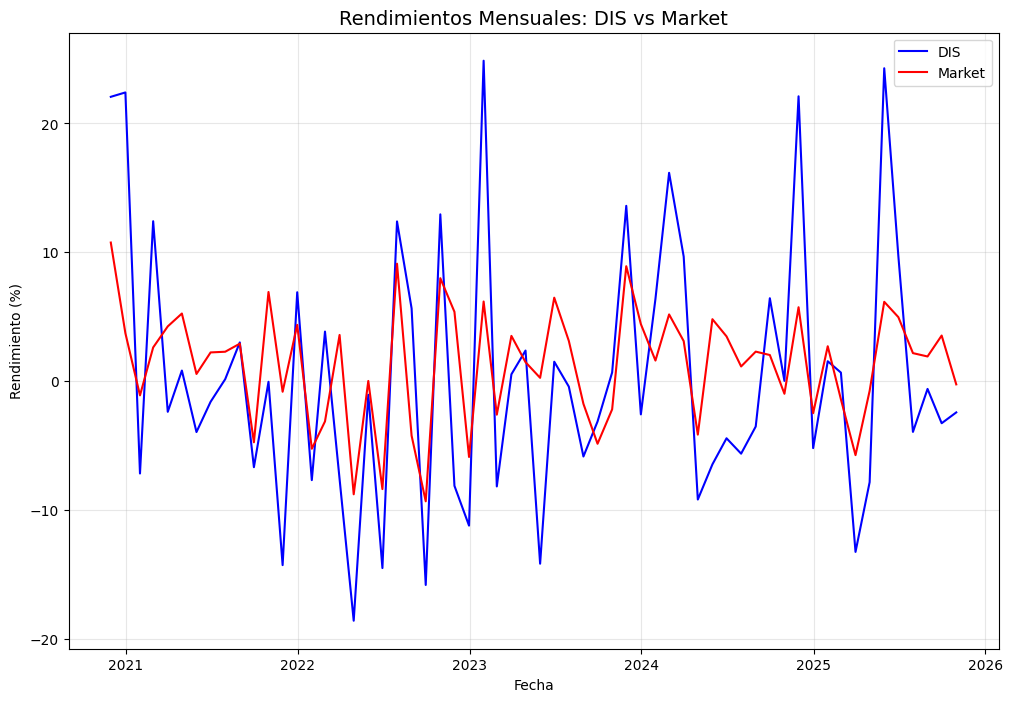

In [52]:
# Copia para graficar
ru = r.copy()

plt.figure(figsize=(12, 8))
plt.plot(r.index, r[TICKER] * 100, label=TICKER, color='blue')
plt.plot(r.index, r['Market'] * 100, label='Market', color='red')

plt.title(f'Rendimientos Mensuales: {TICKER} vs Market', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Rendimiento (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

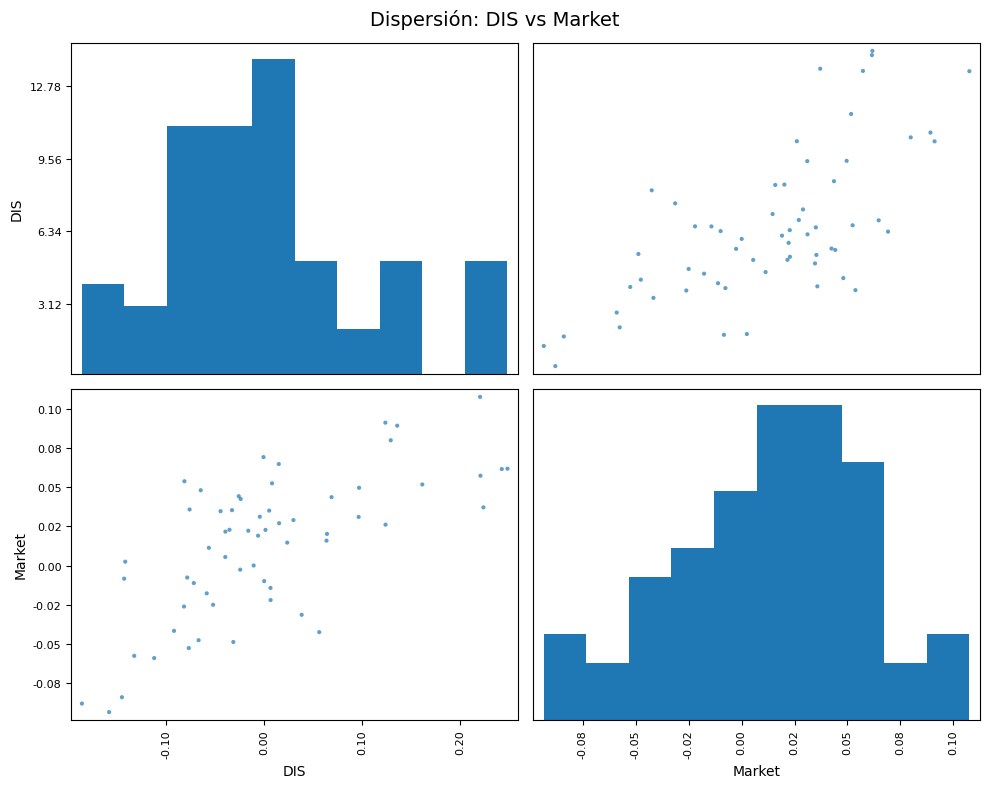

In [54]:
from matplotlib.ticker import FormatStrFormatter
cols = ['DIS', 'Market']

# Crear la matriz de dispersión
axes = scatter_matrix(r[cols], figsize=(10, 8), alpha=0.7, diagonal='hist')

# Título
plt.suptitle('Dispersión: DIS vs Market', fontsize=14)

# Formatear los ejes para que muestren solo 2 decimales
for ax in axes.flatten():
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

Convertimos la columna del índice a periodos mensuales.

In [55]:
r.index = r.index.to_period('M')
r.head()

,DIS,Market
Date,,
2020-11,0.220701,0.107546
2020-12,0.224106,0.037121
2021-01,-0.071807,-0.011137
2021-02,0.124101,0.026091
2021-03,-0.023910,0.042439


**5. Cargamos los datos sobre la tasa libre de riesgo**

In [56]:
rf = pd.read_excel('3M_TBill.xlsx', sheet_name = 'TBill',
                   header=0, index_col=0, parse_dates=True,)
rf

,3M_US_TBill
Date,
2020-10-15,0.104
2020-10-16,0.096
2020-10-19,0.096
2020-10-20,0.101
2020-10-21,0.096
...,...
2025-10-08,3.944
2025-10-09,3.954
2025-10-10,3.947


In [57]:
rf = rf['3M_US_TBill']/100/360
rf.name = 'risk_free'
rf=pd.DataFrame(rf)

In [58]:
rf

,risk_free
Date,
2020-10-15,0.000003
2020-10-16,0.000003
2020-10-19,0.000003
2020-10-20,0.000003
2020-10-21,0.000003
...,...
2025-10-08,0.000110
2025-10-09,0.000110
2025-10-10,0.000110


**6. Importamos el risk kit de AVS**

In [59]:
import avs_risk_kit_3 as ark

Recalculamos los rendimientos a periodos mensuales.

In [60]:
rf_m = rf.resample('M').apply(ark.compound).to_period('M')
rf_m.tail()

/tmp/ipython-input-3477059870.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rf_m = rf.resample('M').apply(ark.compound).to_period('M')


,risk_free
Date,
2025-06,0.002411
2025-07,0.002661
2025-08,0.002468
2025-09,0.002341
2025-10,0.001098


In [61]:
rf_m.head()

,risk_free
Date,
2020-10,0.000032
2020-11,0.000046
2020-12,0.000050
2021-01,0.000042
2021-02,0.000021


**8. Cargamos los datos de los tres factores de Fama-French**

$$
R_{i,t}-R_{f,t}
= \alpha_i
+ \beta_i\,(R_{M,t}-R_{f,t})
+ s_i\,\mathrm{SMB}_t
+ h_i\,\mathrm{HML}_t
+ \varepsilon_{i,t}
$$

In [62]:
df_ff = pd.read_excel('Fama_French.xlsx', sheet_name = '3F_Fama_French',
                   header=0, index_col=0, parse_dates=True,)
df_ff.head()

,MSCI_Small_Price,MSCI_Large_Price,MSCI_Value_Price,MSCI_Growth_Price
Date,,,,
2020-10-15,434.24,1513.58,2533.81,3683.64
2020-10-16,433.52,1516.69,2542.99,3684.07
2020-10-19,431.91,1501.16,2524.22,3644.49
2020-10-20,432.16,1504.34,2528.23,3653.55
2020-10-21,430.83,1501.14,2523.06,3646.31


In [63]:
# Calcular los rendimientos mensuales (returns)
r_ff = (
    df_ff
    .resample('ME')        # Cambiar la frecuencia a mensual
    .last()               # Tomar el último valor de cada mes
    .pct_change()         # Calcular rendimientos porcentuales
    .dropna()             # Eliminar valores NaN iniciales
)

# Mostrar las primeras filas
r_ff.head()

,MSCI_Small_Price,MSCI_Large_Price,MSCI_Value_Price,MSCI_Growth_Price
Date,,,,
2020-11-30,0.152800,0.123503,0.147965,0.108174
2020-12-31,0.072573,0.039812,0.033950,0.049019
2021-01-31,0.020305,-0.011734,-0.011200,-0.009871
2021-02-28,0.049134,0.022041,0.045393,0.003382
2021-03-31,0.019226,0.033272,0.053765,0.007329


**7. Elaboramos una tabla con todos los datos**

In [64]:
# 1) Pasa r (PeriodIndex) a DatetimeIndex en fin de mes
if isinstance(r.index, pd.PeriodIndex):
    r_idx = r.index.to_timestamp('M')
else:
    r_idx = r.index.to_period('M').to_timestamp('M')

r2 = r.copy()
r2.index = r_idx

# 2) Asegura rf_m también en DatetimeIndex fin de mes
if isinstance(rf_m.index, pd.PeriodIndex):
    rf_m2_idx = rf_m.index.to_timestamp('M')
else:
    rf_m2_idx = rf_m.index.to_period('M').to_timestamp('M')

rf_m2 = rf_m.copy()
rf_m2.index = rf_m2_idx

# 3) Unir en el mismo DataFrame que quieres llamar df_general
df_general = r2.join(rf_m2[['risk_free']].rename(columns={'risk_free': 'Risk free rate'}),
                     how='left')

df_general.head()

,DIS,Market,Risk free rate
Date,,,
2020-11-30,0.220701,0.107546,0.000046
2020-12-31,0.224106,0.037121,0.000050
2021-01-31,-0.071807,-0.011137,0.000042
2021-02-28,0.124101,0.026091,0.000021
2021-03-31,-0.023910,0.042439,0.000017


In [65]:
# Asegurar que ambos índices sean DatetimeIndex (fin de mes)
if isinstance(df_general.index, pd.PeriodIndex):
    df_general.index = df_general.index.to_timestamp('M')

if isinstance(r_ff.index, pd.PeriodIndex):
    r_ff.index = r_ff.index.to_timestamp('M')

# Unir ambos DataFrames por la fecha (índice)
df_general = df_general.join(r_ff, how='left')

# Mostrar las primeras filas del DataFrame final
df_general.head()


,DIS,Market,Risk free rate,MSCI_Small_Price,MSCI_Large_Price,MSCI_Value_Price,MSCI_Growth_Price
Date,,,,,,,
2020-11-30,0.220701,0.107546,0.000046,0.152800,0.123503,0.147965,0.108174
2020-12-31,0.224106,0.037121,0.000050,0.072573,0.039812,0.033950,0.049019
2021-01-31,-0.071807,-0.011137,0.000042,0.020305,-0.011734,-0.011200,-0.009871
2021-02-28,0.124101,0.026091,0.000021,0.049134,0.022041,0.045393,0.003382
2021-03-31,-0.023910,0.042439,0.000017,0.019226,0.033272,0.053765,0.007329


**8. Calculamos las primas de riesgo (R) para la empresa y para el índice de mercado**

In [67]:
df_general['Eq Risk Premium']=(df_general['DIS'] -df_general['Risk free rate'])
df_general['Mkt Risk Premium']=(df_general['Market'] -df_general['Risk free rate'])
df_general['SMB']=(df_general['MSCI_Small_Price'] -df_general['MSCI_Large_Price'])
df_general['HML']=(df_general['MSCI_Value_Price'] -df_general['MSCI_Growth_Price'])
df_general.head()

,DIS,Market,Risk free rate,MSCI_Small_Price,MSCI_Large_Price,MSCI_Value_Price,MSCI_Growth_Price,Eq Risk Premium,Mkt Risk Premium,SMB,HML
Date,,,,,,,,,,,
2020-11-30,0.220701,0.107546,0.000046,0.152800,0.123503,0.147965,0.108174,0.220655,0.107500,0.029297,0.039791
2020-12-31,0.224106,0.037121,0.000050,0.072573,0.039812,0.033950,0.049019,0.224056,0.037071,0.032760,-0.015069
2021-01-31,-0.071807,-0.011137,0.000042,0.020305,-0.011734,-0.011200,-0.009871,-0.071849,-0.011179,0.032038,-0.001329
2021-02-28,0.124101,0.026091,0.000021,0.049134,0.022041,0.045393,0.003382,0.124080,0.026070,0.027093,0.042011
2021-03-31,-0.023910,0.042439,0.000017,0.019226,0.033272,0.053765,0.007329,-0.023927,0.042422,-0.014046,0.046436


**9. Calculamos estadísticas para cada una de las variables**

En base a los rendimientos mensuales.

In [68]:
descr_stats= df_general.describe()
descr_stats

,DIS,Market,Risk free rate,MSCI_Small_Price,MSCI_Large_Price,MSCI_Value_Price,MSCI_Growth_Price,Eq Risk Premium,Mkt Risk Premium,SMB,HML
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,0.003637,0.012968,0.001827,0.009088,0.012058,0.010308,0.012686,0.001810,0.011141,-0.002970,-0.002378
std,0.102809,0.045379,0.001287,0.052932,0.043922,0.043261,0.052794,0.102807,0.045348,0.022951,0.037332
min,-0.186133,-0.093396,0.000007,-0.104583,-0.092720,-0.090139,-0.119912,-0.186554,-0.095247,-0.064472,-0.078597
25%,-0.065264,-0.015111,0.000145,-0.030760,-0.020686,-0.019239,-0.019897,-0.067201,-0.017695,-0.016460,-0.025244
50%,-0.008395,0.021940,0.002439,0.007368,0.018401,0.015096,0.020611,-0.009913,0.019334,-0.001863,-0.003978
75%,0.058220,0.043767,0.002994,0.046333,0.041987,0.038739,0.048093,0.056159,0.042710,0.008686,0.022087
max,0.248734,0.107546,0.003491,0.152800,0.123503,0.147965,0.115129,0.246156,0.107500,0.055553,0.079635


Utilizamos el risk kit de AVS para calcular estadísticas financieras.

In [69]:
financial_stats=ark.summary_stats(df_general, riskfree_rate=0.03)
financial_stats

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
DIS,-0.016256,0.356143,0.681212,3.066893,0.143287,0.020389,-0.126791,-0.571255
Market,0.153269,0.157198,-0.390132,2.709828,0.066175,-0.002946,0.763087,-0.247695
Risk free rate,0.022134,0.004457,-0.437533,1.487447,0.000465,NaN,-1.717608,0.000000
MSCI_Small_Price,0.096712,0.183361,0.077012,2.787710,0.076318,0.001041,0.353894,-0.287016
MSCI_Large_Price,0.141796,0.152151,-0.270425,3.025304,0.062849,-0.000984,0.715011,-0.259967
MSCI_Value_Price,0.118814,0.149860,0.184679,3.696265,0.057372,-0.000106,0.576664,-0.201034
MSCI_Growth_Price,0.144484,0.182884,-0.394883,2.886796,0.079269,-0.004435,0.609086,-0.328159
Eq Risk Premium,-0.037722,0.356135,0.684555,3.064807,0.145010,0.022222,-0.185441,-0.589069
Mkt Risk Premium,0.128532,0.157089,-0.375079,2.703209,0.067771,-0.004331,0.610321,-0.253310
SMB,-0.038073,0.079506,0.076147,3.368996,0.039741,0.004902,-0.833337,-0.284444


Presentamos un resumen con los rendimientos anualizados.

In [70]:
annual = ark.annualize_rets(df_general["2020":"2025"], 12)
annual

,0
DIS,-0.016256
Market,0.153269
Risk free rate,0.022134
MSCI_Small_Price,0.096712
MSCI_Large_Price,0.141796
MSCI_Value_Price,0.118814
MSCI_Growth_Price,0.144484
Eq Risk Premium,-0.037722
Mkt Risk Premium,0.128532
SMB,-0.038073


Preparamos un data frame con las primas de riesgo para la elaboración del modelo econométrico.

In [71]:
erp=pd.DataFrame(df_general['Eq Risk Premium'])
mrp=pd.DataFrame(df_general['Mkt Risk Premium'])
smb=pd.DataFrame(df_general['SMB'])
hml=pd.DataFrame(df_general['HML'])

**10. Realizamos la estimación de los coeficientes mediante OLS**

$$
R_{i,t}-R_{f,t}
= \alpha_i
+ \beta_i\,(R_{M,t}-R_{f,t})
+ s_i\,\mathrm{SMB}_t
+ h_i\,\mathrm{HML}_t
+ \varepsilon_{i,t}
$$

In [72]:
# Variables dependiente e independientes
y = df_general['Eq Risk Premium']             # Variable dependiente (exceso de rendimiento del activo)
X = df_general[['Mkt Risk Premium', 'SMB', 'HML']]  # Factores explicativos

# Agregar constante al modelo
X = sm.add_constant(X)

# Estimar el modelo OLS
modelo_ff3 = sm.OLS(y, X).fit()

# Mostrar resultados
print(modelo_ff3.summary())

                            OLS Regression Results                            
Dep. Variable:        Eq Risk Premium   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                     19.54
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           8.59e-09
Time:                        20:23:54   Log-Likelihood:                 73.347
No. Observations:                  60   AIC:                            -138.7
Df Residuals:                      56   BIC:                            -130.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0119      0.010  

Corregimos los errores estandar para que sean robustos.

In [73]:
# Agregar constante al modelo
X = sm.add_constant(X)

# Estimar el modelo OLS
modelo_ff3 = sm.OLS(y, X).fit(cov_type='HC3')

# Mostrar resultados
print(modelo_ff3.summary())

                            OLS Regression Results                            
Dep. Variable:        Eq Risk Premium   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                     24.40
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           3.16e-10
Time:                        20:24:08   Log-Likelihood:                 73.347
No. Observations:                  60   AIC:                            -138.7
Df Residuals:                      56   BIC:                            -130.3
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0119      0.010  

In [74]:
# Coeficientes del modelo
coef_mkt_risk_premium = modelo_ff3.params['Mkt Risk Premium']
coef_smb = modelo_ff3.params['SMB']
coef_hml = modelo_ff3.params['HML']

# Valores anuales de los factores
mkt_risk_premium_annual = annual['Mkt Risk Premium']
smb_annual = annual['SMB']
hml_annual = annual['HML']
risk_free_rate_annual = annual['Risk free rate']

# Cálculo del retorno esperado bajo el modelo Fama-French
expected_return = (coef_mkt_risk_premium * mkt_risk_premium_annual +
                   coef_smb * smb_annual +
                   coef_hml * hml_annual +
                   risk_free_rate_annual)

# Mostrar el retorno esperado
print(f"Expected Return (Fama-French): {expected_return}")

Expected Return (Fama-French): 0.17676176377971486


In [75]:
modelo_ff3.params

,0
const,-0.011850
Mkt Risk Premium,1.465016
SMB,0.958407
HML,-0.077852
